<div style="font-family:verdana;"><span style="font-size:400%;"> <center>Module 1: ECDF and Rank-Based Tests</center> </span>
    
</div>





# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">Contents</p>

**<a href=#1.-Introduction>1. Introduction</a>**

**<a href=#2.-Empirical-Cumulative-Distribution-Function>2. Empirical Cumulative Distribution Function</a>**

**<a href=#3.-Sign-Test>3. Sign Test</a>**

**<a href=#4.-Mann-Whitney-Framework>4. Mann-Whitney Framework</a>**

**<a href=#5.-Conclusion>5. Conclusion</a>**

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">1. Introduction</p>

This notebook introduces three foundational ideas in nonparametric statistics:

1. the **empirical cumulative distribution function (ECDF)**,
2. the **sign test**,
3. the **Mann–Whitney framework**.

These methods are a good starting point because they illustrate three different aspects of nonparametric reasoning:

- **estimation without a fixed distributional form**,
- **inference based on limited information such as signs**,
- **comparison of samples through ordering rather than through mean-variance structure alone**.

In classical parametric statistics, one often begins with a model family such as the normal distribution and then estimates a finite set of parameters. In nonparametric statistics, the goal is often to weaken those structural assumptions and let the data determine more of the shape of the problem.

This notebook is therefore not only about three specific tools. It is also about a way of thinking: what can be learned from data when we refuse to assume too much in advance?

## 📙 Import libraries and modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from nonparametric_stats.ecdf import ecdf
from nonparametric_stats.rank_tests import sign_test, mann_whitney_pairwise_less

## ⚙️ Configuration

In [2]:
rng = np.random.default_rng(42)

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">2. Empirical Cumulative Distribution Function</p>

The empirical cumulative distribution function is one of the most basic nonparametric estimators in all of statistics.

If a sample is given by $(x_1, x_2, \dots, x_n)$, the ECDF is defined as

$$
F_n(t) = \frac{1}{n}\sum_{i=1}^n \mathbf{1}(x_i \le t).
$$

This means that for any value $t$, the ECDF tells us the proportion of sample points less than or equal to $t$.

### Why this matters

This is a genuinely nonparametric object. We are not assuming that the data come from a normal distribution, an exponential distribution, or any other named parametric family. We are simply estimating the distribution function directly from the sample.

### Intuition

The ECDF is a step function. Each observed data point contributes an upward jump of size $(1/n)$. The function therefore records the cumulative mass of the data exactly as observed.

### Why it is important pedagogically

The ECDF is useful for learning statistics because it shows that a distribution can be estimated without fitting a named family. That is a central nonparametric idea: estimation can begin with the data themselves, not only with a parametric assumption.

In [3]:
x = rng.exponential(scale=1.0, size=100)
xs, ys = ecdf(x)

ecdf_preview = pd.DataFrame({
    "x_sorted": xs[:10],
    "F_n(x)": ys[:10]
})

ecdf_preview

,x_sorted,F_n(x)
0,0.021140,0.01
1,0.044454,0.02
2,0.049751,0.03
3,0.054673,0.04
4,0.070436,0.05
5,0.073028,0.06
6,0.075739,0.07
7,0.077077,0.08
8,0.079294,0.09
9,0.086437,0.10


The table above shows the first few sorted values and the corresponding ECDF levels. Because the ECDF increases by $1/n$ at each observed point, the second column increases in equal increments.

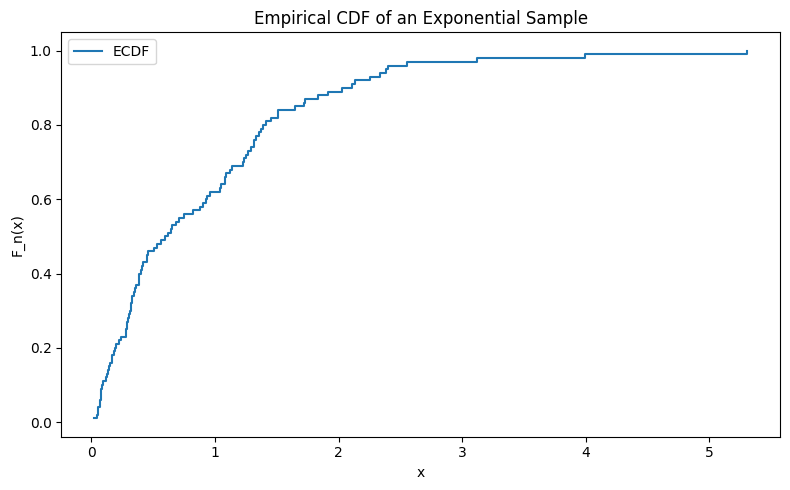

In [4]:
plt.figure(figsize=(8, 5))
plt.step(xs, ys, where="post", label="ECDF")
plt.xlabel("x")
plt.ylabel("F_n(x)")
plt.title("Empirical CDF of an Exponential Sample")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/ecdf_exponential_sample.png", dpi=150, bbox_inches="tight")
plt.show()

The step-function shape is the defining visual feature of the ECDF. Unlike a smooth theoretical CDF, the empirical CDF changes only when the sample itself changes.

### ECDF versus the true distribution

Because the data here were simulated from an exponential distribution, we can compare the ECDF with the true population CDF. This is useful for developing intuition, even though in real applications the true CDF is generally unknown.

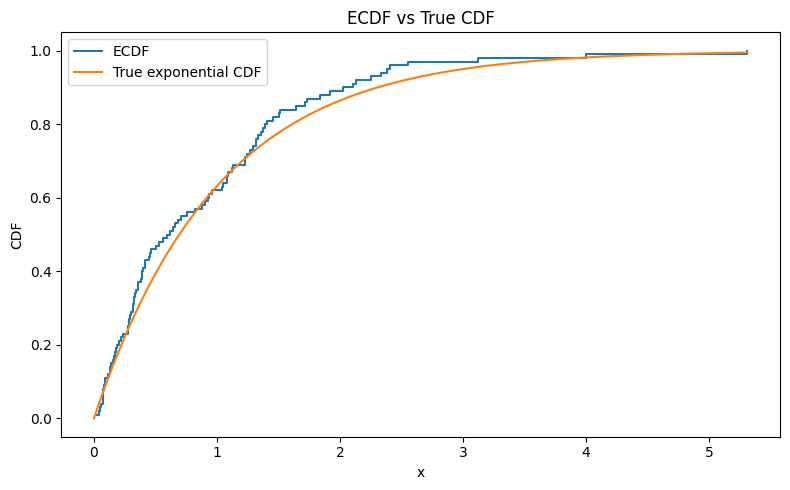

,quantity,value
0,Sample size,100.000000
1,Kolmogorov-style sup error,0.088287


In [5]:
grid = np.linspace(0, xs.max(), 500)
true_cdf = stats.expon.cdf(grid, scale=1.0)

ecdf_on_grid = np.interp(grid, xs, ys, left=0.0, right=1.0)
sup_error = np.max(np.abs(ecdf_on_grid - true_cdf))

plt.figure(figsize=(8, 5))
plt.step(xs, ys, where="post", label="ECDF")
plt.plot(grid, true_cdf, label="True exponential CDF")
plt.xlabel("x")
plt.ylabel("CDF")
plt.title("ECDF vs True CDF")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/ecdf_vs_true_cdf.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame({
    "quantity": ["Sample size", "Kolmogorov-style sup error"],
    "value": [len(x), sup_error]
})

The ECDF tracks the true CDF reasonably well, though it remains jagged because it is built from finitely many observations.

The supremum error shown above measures the largest vertical discrepancy between the empirical and true CDFs over the grid. This is closely related to the logic behind Kolmogorov-style goodness-of-fit ideas.

### What to learn from this

The ECDF is not just a plotting device. It is a full estimator of the distribution function. In many ways it is the canonical nonparametric estimator: simple, direct, and assumption-light.

### Strengths and limitations of the ECDF

**Strengths**
- requires no fixed parametric family,
- uses all observations directly,
- gives a complete estimate of the distribution function,
- forms the basis for several important tests and asymptotic results.

**Limitations**
- it is a step function rather than a smooth estimator,
- it can be visually rough in small samples,
- it does not directly summarize the data into a low-dimensional parameter.

This tradeoff is typical in nonparametric statistics: less structure, more flexibility, but often less compression and less smoothness.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">3. Sign Test</p>

The sign test is one of the simplest examples of nonparametric inference.

Suppose we observe paired differences $d_1, d_2, \dots, d_n$. The sign test asks whether the median difference is zero. Instead of using the magnitudes of the $d_i$, it uses only whether each difference is positive or negative.

### Why this is interesting

The sign test shows that valid inference can sometimes be built from very limited information. It intentionally throws away magnitudes and retains only direction.

### What is gained by doing this?

By ignoring magnitudes, the sign test becomes less sensitive to outliers and heavy-tailed behavior.

### What is lost?

Because it discards information, it is often less powerful than a parametric mean-based test when parametric assumptions are appropriate.

This is an important lesson: robustness often comes at the cost of efficiency.

### Formal setup

Under the null hypothesis that the median difference is zero, positive and negative signs should occur with equal probability, ignoring ties. This reduces the problem to a binomial counting argument.

In [6]:
diffs = rng.normal(loc=0.4, scale=1.0, size=20)

sign_result = sign_test(diffs)

sign_summary = pd.DataFrame({
    "quantity": ["Effective sample size", "Positive differences", "Two-sided p-value"],
    "value": [sign_result["n"], sign_result["n_pos"], sign_result["p_value"]]
})

sign_summary

,quantity,value
0,Effective sample size,20.000000
1,Positive differences,13.000000
2,Two-sided p-value,0.263176


The effective sample size excludes exact zero differences, because zero contributes no directional information. The test then counts how many of the remaining observations are positive.

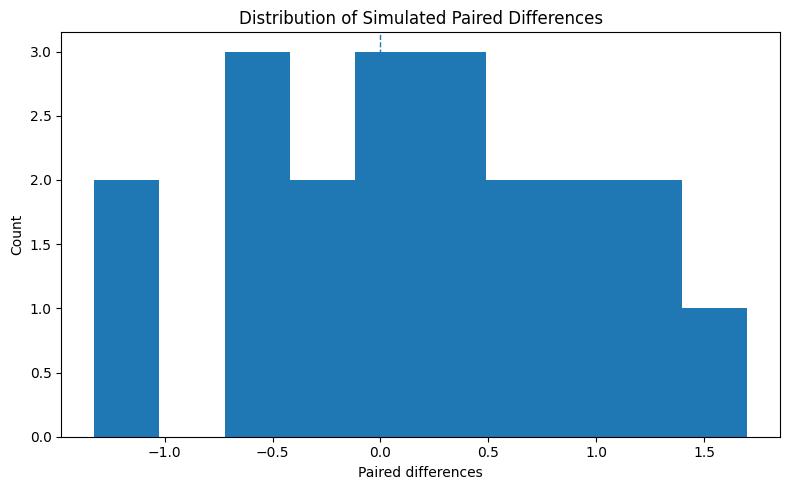

In [7]:
plt.figure(figsize=(8, 5))
plt.axvline(0.0, linestyle="--", linewidth=1)
plt.hist(diffs, bins=10)
plt.xlabel("Paired differences")
plt.ylabel("Count")
plt.title("Distribution of Simulated Paired Differences")
plt.tight_layout()
plt.savefig("../reports/figures/sign_test_differences_hist.png", dpi=150, bbox_inches="tight")
plt.show()

The histogram helps clarify what the sign test is doing. Although the data have magnitudes, the sign test uses only whether each value falls to the left or right of zero.

### Comparison with the one-sample t-test

To sharpen the contrast, it is useful to compare the sign test with a classical one-sample t-test. The two methods are related, but they are not identical in either target or mechanism.

In [8]:
ttest_result = stats.ttest_1samp(diffs, popmean=0.0)

comparison = pd.DataFrame({
    "method": ["Sign test", "One-sample t-test"],
    "statistic": [np.nan, ttest_result.statistic],
    "p_value": [sign_result["p_value"], ttest_result.pvalue]
})

comparison

,method,statistic,p_value
0,Sign test,NaN,0.263176
1,One-sample t-test,1.134079,0.270868


### Interpretation

The one-sample t-test is built around the sample mean and a parametric reference distribution for the test statistic. The sign test is instead built around a binomial counting argument based only on sign information.

The t-test typically has more power when the data are well behaved and magnitudes are informative. The sign test is more robust when magnitudes are unstable or misleading.

### Pedagogical importance

The sign test teaches a deep statistical lesson: inference does not always require sophisticated distributional machinery. Sometimes a simple invariance or symmetry argument is enough.

### Strengths and limitations of the sign test

**Strengths**
- simple and exact,
- robust to large outliers,
- weak distributional requirements,
- easy to interpret.

**Limitations**
- discards magnitude information,
- often lower power than alternatives,
- targets median behavior rather than mean behavior.

This is one of the cleanest examples of the robustness-efficiency tradeoff.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">4. Mann-Whitney Framework</p>

The Mann–Whitney procedure is often introduced as “the nonparametric alternative to the two-sample t-test.” That description is convenient, but incomplete.

A more illuminating interpretation is that the method compares two samples through their pairwise ordering behavior.

### Core idea

If $X$ and $Y$ are random draws from two populations, a natural question is:

$$
P(X < Y)
$$

How often is a draw from one population less than a draw from the other?

This pairwise-ordering perspective is one of the most useful ways to understand the Mann–Whitney framework.

In [9]:
x = rng.normal(0.0, 1.0, size=30)
y = rng.normal(0.5, 1.0, size=35)

group_summary = pd.DataFrame({
    "group": ["x", "y"],
    "n": [len(x), len(y)],
    "mean": [np.mean(x), np.mean(y)],
    "median": [np.median(x), np.median(y)],
    "std": [np.std(x, ddof=1), np.std(y, ddof=1)]
})

group_summary

,group,n,mean,median,std
0,x,30,-0.006693,-0.181507,1.132790
1,y,35,0.491662,0.446217,0.920714


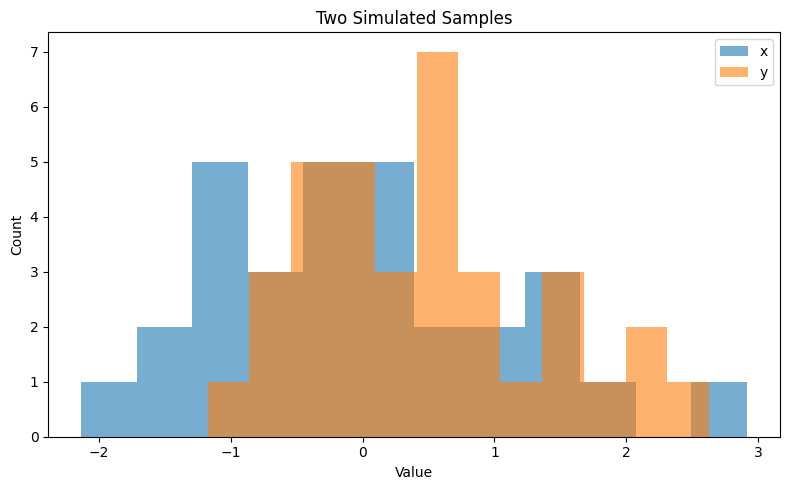

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(x, bins=12, alpha=0.6, label="x")
plt.hist(y, bins=12, alpha=0.6, label="y")
plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Two Simulated Samples")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/mann_whitney_group_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

The two groups appear shifted relative to one another, though they still overlap substantially. This is exactly the kind of setting in which an ordering-based comparison is informative.

In [11]:
pairwise_less = mann_whitney_pairwise_less(x, y)
u_scipy = stats.mannwhitneyu(x, y, alternative="two-sided").statistic
prob_x_less_y = pairwise_less / (len(x) * len(y))

mw_summary = pd.DataFrame({
    "quantity": [
        "Pairwise less-than count",
        "SciPy U for x",
        "Estimated P(X < Y)"
    ],
    "value": [
        pairwise_less,
        u_scipy,
        prob_x_less_y
    ]
})

mw_summary

,quantity,value
0,Pairwise less-than count,683.000000
1,SciPy U for x,367.000000
2,Estimated P(X < Y),0.650476


### Why are the pairwise count and SciPy's $U$ different?

Our manual quantity counts how often $x_i < y_j$, with half-credit for ties. SciPy’s reported $U$ statistic is the conventional statistic attached to the first sample. These quantities are closely related, but they are not numerically identical.

The pairwise-probability interpretation is often easier to understand conceptually, which is why it is emphasized here.

### Interpretation

Dividing the pairwise count by $nm$ gives an estimate of the probability that a random observation from sample $X$ is less than a random observation from sample $Y$.

This perspective is valuable because it reveals that the Mann–Whitney framework is about relative ordering, not just about replacing one test with another.

### Relation to the two-sample t-test

The two-sample t-test compares means. The Mann–Whitney framework instead compares relative ordering structure. In some simple shift models these may point in similar directions, but they are conceptually distinct.

This matters because nonparametric methods are not merely “backup versions” of parametric methods. They often target somewhat different features of the data.

### Strengths and limitations of the Mann–Whitney framework

**Strengths**
- uses ordering rather than normal-theory assumptions,
- robust to some forms of non-normality,
- admits a clear pairwise probability interpretation,
- often effective for continuous two-sample comparisons.

**Limitations**
- not identical in meaning to a mean comparison,
- interpretation becomes subtler when shapes differ strongly,
- can be oversimplified when taught merely as a substitute for the t-test.

This is an especially important method pedagogically because it reveals how much can be done with ranks and order alone.

# <p style="background-color:darkred;color:white;font-family:verdana;font-size:120%;text-align:center;border-radius: 15px 50px;">5. Conclusion</p>

## 4. What this notebook teaches about nonparametric statistics

The three examples in this notebook illustrate a common theme.

- The **ECDF** estimates a full distribution function without assuming a named family.
- The **sign test** builds inference from signs alone.
- The **Mann–Whitney framework** compares samples through ordering and pairwise probabilities.

Together, they show that nonparametric statistics is not one single trick. It is a broad strategy for learning from data under weaker structural assumptions.

### General lesson

Parametric statistics often gains efficiency by imposing form. Nonparametric statistics often gains robustness and flexibility by relaxing form.

Neither approach dominates universally. The important thing is to understand what assumptions one is making, what feature of the data one is targeting, and what information one is willing to discard or retain.

In [12]:
final_summary = pd.DataFrame({
    "method": ["ECDF", "Sign test", "Mann–Whitney framework"],
    "main target": [
        "Distribution function",
        "Median difference via sign information",
        "Relative ordering between two samples",
    ],
    "key nonparametric idea": [
        "Estimate without a fixed family",
        "Inference from signs alone",
        "Inference from ranks/pairwise comparisons",
    ],
})

final_summary

,method,main target,key nonparametric idea
0,ECDF,Distribution function,Estimate without a fixed family
1,Sign test,Median difference via sign information,Inference from signs alone
2,Mann–Whitney framework,Relative ordering between two samples,Inference from ranks/pairwise comparisons


### Final Takeaway

This first module introduces the logic of nonparametric statistics through estimation, testing, and sample comparison.

The deeper point is not just how to run these procedures. It is how to think statistically when one does not want to assume that the world has a neat parametric form in advance.